<p align="center">
  <span style="color:Navy; font-size:170%; font-weight:bold; vertical-align:middle;">
    Temas Selectos: Python para Ciencias de la Tierra
  </span>
  <img src="https://educacioncontinua.unam.mx/uploads_img/LOGO_ENCIT.png" alt="ENCiT" width="150" style="vertical-align:middle; margin-left:20px;"/>
</p>
<p align="center" style="line-height:1.2;">
  <span style="color:RoyalBlue; font-size:160%;">Tema 2: Manejo de datos</span><br/>
  <span style="color:DodgerBlue; font-size:140%;"> Métodos de regresión e interpolación </span><br/>
  <span style="font-size:100%;color:forestgreen"> Escuela Nacional de Ciencias de la Tierra  |  Semestre 2027-I</span>
</p>

---

# <font color = blue> Estimación </font>

La estimación puede lograrse de dos maneras:

* Ajustando una función que minimice las distancias del punto tabulado a la función (regresión) o
* Ajustando una función que toque todos los puntos de la tabla (interpolación). 

La función de la interpolación pasa por cada punto de la tabla, la función de la regresión no necesariamente pasa lo más cerca de los puntos. Esto es, si sustituimos $x_i$ en $f(x)$, el resultado es $y_i$ para la interpolación y para la regresión obtenemos $y_i$ corregida

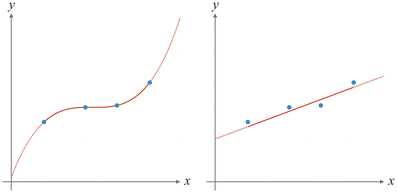

---
# <font color="blue"> Métodos de regresión </font>

## ¿Qué es un modelo de regresión?

Un modelo de **regresión** busca una función matemática que describa, de la mejor forma posible, la relación entre una **variable dependiente** (la que queremos explicar o predecir, por ejemplo la concentración de un contaminante) y una o más **variables independientes** (las que usamos para explicarla, por ejemplo la distancia a un río).

La regresión ajusta **una sola función** que representa la tendencia general de los datos, esta línea de tendecia no pasa exáctamente por todos los puntos, sino que se acerca lo más posible a todos ellos en conjunto.

## Datos reales: el CO2 atmosférico de Mauna Loa

Desde 1958, el Observatorio de Mauna Loa (Hawái) mide de forma continua la concentración de CO2 en la atmósfera. Este registro, iniciado por Charles David Keeling, es una evidencia famosa del aumento del CO2 atmosférico y se conoce como la **Curva de Keeling**.

*Fuente: Dr. Pieter Tans, NOAA Global Monitoring Laboratory, y Dr. Ralph Keeling, Scripps Institution of Oceanography (dominio público).*

https://gml.noaa.gov/ccgg/trends/data.html

In [ ]:
# las librerías que necesitaremos son las siguientes: 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import CubicSpline, griddata
from sklearn.linear_model import LinearRegression

In [ ]:
# Paso 1: Importar los datos directamente del enlace de la NOAA
url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"

columnas_co2 = ["Anio","mes","fecha_decimal", "co2_ppm", "co2_ppm_interpolado",
                "dias_muestreo", "desv_estandar", "incertidumbre"]

co2 = pd.read_csv("https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv", skiprows = 41, header=None, names=columnas_co2)
co2.head()

In [ ]:
# Un poco de organizacion y limpieza
co2['fecha'] = co2['Anio'].astype(str) + '-' + co2['mes'].astype(str)
co2["fecha"] = pd.to_datetime(co2["fecha"], format = "%Y-%m")



In [ ]:
# inspeccionamos la informacion del DataFrame


In [ ]:
## Creen un grafico simple de la serie temporal de concentracion de CO2 



Observa dos cosas en la gráfica: una **tendencia** creciente de largo plazo, y un **ciclo estacional** causado por la fotosíntesis en el hemisferio norte. En esta sección nos enfocaremos en modelar la tendencia con regresión.

## <font color=blue> Regresión lineal simple </font>

El modelo más simple es una línea recta:

$$y = m \cdot x + b$$

Usaremos `scipy.stats.linregress()`, una función pensada específicamente para estadística, que además de la pendiente (*m*) y la ordenada al origen (*b*) nos da el **coeficiente de correlación (r)** y su cuadrado, **R²**, que mide qué proporción de la variabilidad de *y* es explicada por el modelo (entre 0 y 1; entre más cercano a 1, mejor el ajuste).

Para más información de cómo funciona: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.linregress.html

In [ ]:
x = co2["fecha_decimal"].values   # año en formato decimal, p. ej. 2020.5
y = co2["co2_ppm"].values

#
pendiente, ordenada, r, p_valor, error_estandar = stats.linregress(x, y)

print(f"Pendiente (m): {pendiente:.3f} ppm/año")
print(f"Intercepto (b): {ordenada:.2f}")
print(f"Coeficiente de correlación (r): {r:.4f}")
print(f"R² : {r**2:.4f}")
#h0 = la pendiente es cero
print(f"Valor p :{p_valor:.1f}")

La pendiente nos dice que, en promedio, el CO2 atmosférico ha aumentado cerca de **1.7 ppm por año** en todo el periodo registrado. El **R² tan cercano a 1** indica que una simple línea recta ya explica la gran mayoría de la variación de los datos, aunque como veremos, no es un ajuste perfecto.

Grafiquemos los datos junto con la recta ajustada:

In [ ]:
y_pred_lineal = pendiente * x + ordenada

plt.figure(figsize=(6, 3))
plt.scatter(co2["fecha"], y, s=3, color="gray", alpha=0.5, label="Datos observados")
plt.plot(co2["fecha"], y_pred_lineal, color="navy", linewidth=2,
         label=f"Ajuste lineal (R² = {r**2:.3f})")
plt.xlabel("Año")
plt.ylabel("CO2 (ppm)")
plt.title("Regresión lineal simple: CO2 vs. tiempo")
plt.legend()
plt.show()

### Ejercicio
Usando la pendiente y la ordenada al origen de `stats.linregress` que ya calculamos:

1. Predice la concentración de CO2 para el año **2035** con el modelo lineal.
2. Compara esa predicción con el último valor real registrado en el dataset (`co2["co2_ppm"].iloc[-1]`). ¿La predicción es mayor o menor?
3. Ahora predice para el año **1970** y compara con el valor real más cercano en los datos de ese año (usa `co2[co2["fecha_decimal"].between(1970, 1971)]`). ¿Qué tan cerca está la predicción del valor real?

## ¿Qué tan bueno es el ajuste? Los residuales

Un **residual** es la diferencia entre el valor observado y el valor que predice el modelo: $\text{residual} = y_{real} - y_{predicho}$. Si el modelo captura bien la estructura de los datos, los residuales deberían verse como ruido aleatorio, sin ningún patrón.

In [ ]:
#calcula los valores residuales para cada punto del conjuto de datos
residuales_lineal = _____________________________

#Grafica los residuos 
plt.figure(figsize=(6, 3))
plt.scatter(__________, _______________, s=3, color="darkorange", alpha=0.6)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Año")
plt.ylabel("Residual (ppm)")
plt.title("Residuales del ajuste lineal")
plt.show()

Fíjate en el patrón: los residuales **no** son ruido aleatorio. Tienen forma de "U", positivos al inicio y al final, y negativos en la parte media. Esto es una señal clara de que una simple línea recta no es suficiente para describir el comportamiento: **el CO2 no crece de forma constante, crece cada vez más rápido**. Necesitamos un modelo más flexible.

## <font color = blue> Regresión polinomial </font>

Un polinomio de grado 2 (cuadrático) permite capturar curvaturas:

$$y = a \cdot x^2 + b \cdot x + c$$

Usamos `np.polyfit(x, y, grado)`, que generaliza a cualquier grado.

Para más información: https://numpy.org/devdocs/reference/generated/numpy.polyfit.html

In [ ]:
#Primero obtenemos los coeficientes a,b y c
coef_cuadratico = np.polyfit(x, y, 2)
#Ahora hacemos las predicciones considerando el ajuste
y_pred_cuadratico = np.polyval(coef_cuadratico, x)

# Calculamos R² manualmente: 1 - (suma de cuadrados residual / suma de cuadrados total)
ss_res = np.sum((y - y_pred_cuadratico) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2_cuadratico = 1 - ss_res / ss_tot

print("Coeficientes [a, b, c]:", coef_cuadratico)
print(f"R² del modelo cuadrático: {r2_cuadratico:.4f}   (lineal era {r**2:.4f})")

In [ ]:
plt.figure(figsize=(6, 3))
plt.scatter(co2["fecha"], y, s=3, color="gray", alpha=0.5, label="Datos observados")
plt.plot(co2["fecha"], y_pred_lineal, color="navy", linewidth=2, label="Lineal")
# Grafiquen el nuevo ajuste
_______________________________________________
plt.xlabel("Año")
plt.ylabel("CO2 (ppm)")
plt.title("Comparación: ajuste lineal vs. cuadrático")
plt.legend()
plt.show()

El modelo cuadrático sigue mucho mejor la curvatura real de los datos, y su R² es más alto. Esto confirma numéricamente que **el crecimiento del CO2 se está acelerando**.

### Ejercicio 

1. Ajusta un polinomio de **grado 3** a los mismos datos (`np.polyfit(x, y, 3)`).
2. Calcula su R² (con la misma fórmula que usamos arriba) y compáralo con el del modelo cuadrático.
3. Grafica los tres modelos juntos (lineal, cuadrático, grado 3) sobre los datos.
4. En una frase, ¿el modelo de grado 3 mejora mucho, poco, o nada respecto al cuadrático? ¿Vale la pena la complejidad extra?

## El peligro de extrapolar

**Extrapolar** es usar un modelo para predecir fuera del rango de datos con el que fue ajustado (en este caso, fuera de 1958–2026). Es tentador hacerlo, pero es arriesgado: el modelo no "sabe" nada sobre lo que ocurre fuera de ese rango, solo continúa la forma matemática con la que fue construido.

In [ ]:
for year in [2050, 2100, 3000]:
    pred_lineal = pendiente * year + ordenada
    pred_cuadratico = np.polyval(coef_cuadratico, year)
    print(f"Año {year}: modelo lineal = {pred_lineal:8.1f} ppm   |   modelo cuadrático = {pred_cuadratico:10.1f} ppm")

Para el año 3000, el modelo cuadrático predice más de **15,000 ppm** (un valor sin ningún sentido físico). El problema no es que el modelo esté mal; es que lo estamos usando muy lejos de donde tiene evidencia que lo respalde. 

**Regla general: estima con confianza dentro del rango de tus datos; extrapola con mucha cautela, y nunca muy lejos de ese rango.**

## <font color=blue >Metales pesados en el suelo (dataset Meuse) </font>

Estos datos contienen concentraciones de metales pesados (cadmio, cobre, plomo, zinc) medidas en 155 puntos del suelo al rededor de la llanura del río Mosa (Meuse), cerca de Stein, Países Bajos, junto con variables como la distancia al río y la elevación relativa. Estos datos fueron obtenidos posterior a una inundacion.


*Fuente: Burrough, P.A. y McDonnell, R.A. (1998). Principles of Geographical Information Systems. Oxford University Press. Datos compilados por Edzer Pebesma (paquete `sp`/`gstat` de R).*

In [ ]:
#Primero cargamos los datos
url_meuse = "https://raw.githubusercontent.com/lizhouf/oscr2019/master/Machine_Learning/Linear_Regression/Python/soil.csv"
#Abran el archivo con pandas usando read_csv
meuse = _________________________
#Renombren la columna "dist.m" por  "dist_m"
meuse = _____________________________________

meuse.head()

In [ ]:
#inspeccionamos el DataFrame
_____________________

Columnas clave que usaremos:

| Columna | Significado |
|---|---|
| `x`, `y` | Coordenadas (metros, sistema de coordenadas neerlandés RDH) |
| `zinc`, `lead`, `cadmium`, `copper` | Concentración del metal en el suelo (mg/kg) |
| `dist` | Distancia normalizada al río Meuse (0 = en la orilla, 1 = lo más lejos del área de estudio) |
| `elev` | Elevación relativa sobre el nivel del río (m) |
| `om` | Materia orgánica en el suelo (%) |

## <font color =blue> Regresión múltiple </font>

### Regresión simple zinc vs. distancia al río
Para más información sobre este otro método:
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [ ]:
X = meuse[["dist"]].values   # scikit-learn espera una matriz 2D de variables (aunque sea una sola)
y_zinc = meuse["zinc"].values

modelo_simple = LinearRegression()
modelo_simple.fit(X, y_zinc)

print("Pendiente:", round(modelo_simple.coef_[0], 1))
print("Ordenada al origen:", round(modelo_simple.intercept_, 1))
print("R²:", round(modelo_simple.score(X, y_zinc), 3))

In [ ]:

plt.figure(figsize=(7, 4.5))
#Creen el grafico de dispresion Zinc en el suelo vs. distancia al río Meuse

______________________________________________
#Graficamos la recta ajustada 
x_linea = np.linspace(meuse["dist"].min(), meuse["dist"].max(), 100).reshape(-1, 1)
plt.plot(x_linea, modelo_simple.predict(x_linea), color="black", linewidth=2)
plt.xlabel("Distancia normalizada al río")
plt.ylabel("Zinc (mg/kg)")
plt.title("Zinc en el suelo vs. distancia al río Meuse")
plt.show()

La pendiente es negativa: **a mayor distancia del río, menor concentración de zinc**.

### Ejercicio

Repite el mismo procedimiento (ajustar y graficar una regresión lineal simple con `LinearRegression`), pero ahora para el **plomo** (`"lead"`) en función de `"dist"`. Imprime la pendiente, la ordenada al origen y el R². ¿El R² es mayor o menor que el que obtuvimos con zinc?

Cuando una sola variable no es suficiente para describir el comportamiento de los datos, la **regresión múltiple** es otra opcion. Esta combina varias variables explicativas en un solo modelo:

$$y = b_0 + b_1 x_1 + b_2 x_2 + \dots$$

### <font color = blue> Regresión múltiple zinc en función de distancia y elevación </font>

In [ ]:
X_multiple = meuse[["dist", "elev"]].values

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_multiple, y_zinc)

print("Coeficientes [dist, elev]:", np.round(modelo_multiple.coef_, 1))
print("Intercepto:", round(modelo_multiple.intercept_, 1))
print("R²:", round(modelo_multiple.score(X_multiple, y_zinc), 3))

---
# <font color =blue > Métodos de interpolación </font>

## Interpolación vs. regresión: ¿cuál es la diferencia?

Es fácil confundirlas porque ambas "rellenan información" a partir de datos conocidos:

| | **Regresión** | **Interpolación** |
|---|---|---|
| Objetivo | Encontrar la **tendencia general** que mejor resume los datos | Estimar valores **exactamente entre** los puntos conocidos |
| ¿Pasa por los puntos originales? | Normalmente no (minimiza el error total) | Sí, casi siempre pasa exactamente por ellos |
| ¿Sirve para extrapolar? | A veces, con mucho cuidado | No — solo es confiable **dentro** del rango muestreado |
| Ejemplo en este notebook | La tendencia del CO2 a lo largo de décadas | El valor de CO2 en un mes específico que no se midió |

En pocas palabras: la regresión busca **la forma general** de la relación; la interpolación busca **el mejor valor puntual** entre datos conocidos.

## <font color =blue >Interpolación 1D: rellenar huecos en una serie de tiempo real </font>

Vamos a ocultar deliberadamente algunos valores **reales** de CO2 (fingiendo que no los medimos), interpolarlos, y comparar la estimación contra el valor real que sabemos que ocurrió. Así podemos medir qué tan buena es la interpolación.

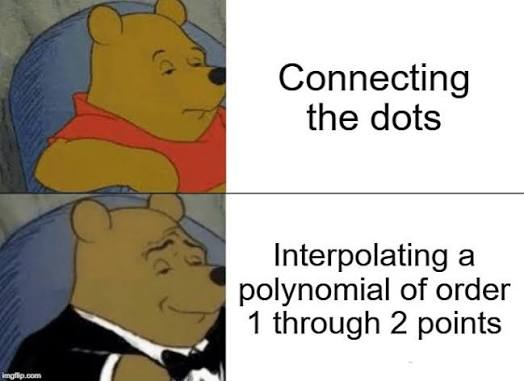

In [ ]:
np.random.seed(3)

# Trabajamos con una ventana de 5 años para que sea fácil de visualizar
ventana = co2[(co2["fecha_decimal"] >= 2015) & (co2["fecha_decimal"] < 2020)].reset_index(drop=True)

# Ocultamos 6 meses reales al azar (evitando los extremos de la ventana)
indices_ocultos = np.sort(np.random.choice(ventana.index[3:-3], size=6, replace=False))
visibles = ventana.drop(index=indices_ocultos)

x_conocidos = visibles["fecha_decimal"].values
y_conocidos = visibles["co2_ppm"].values

x_ocultos = ventana.loc[indices_ocultos, "fecha_decimal"].values
y_real = ventana.loc[indices_ocultos, "co2_ppm"].values

print("Meses que ocultamos:")
print(ventana.loc[indices_ocultos, ["fecha", "co2_ppm"]])

https://numpy.org/doc/stable/reference/generated/numpy.interp.html

In [ ]:
# Interpolación lineal (conecta los puntos conocidos con rectas)
y_interp_lineal = np.interp(x_ocultos, x_conocidos, y_conocidos)

# Interpolación con spline cúbico (curva suave que pasa por todos los puntos conocidos)
spline = CubicSpline(x_conocidos, y_conocidos)
y_interp_spline = spline(x_ocultos)

comparacion = pd.DataFrame({
    "fecha": ventana.loc[indices_ocultos, "fecha"].values,
    "valor_real": y_real,
    "interp_lineal": np.round(y_interp_lineal, 2),
    "interp_spline": np.round(y_interp_spline, 2),
})
comparacion["error_lineal"] = np.round(np.abs(comparacion["valor_real"] - comparacion["interp_lineal"]), 3)
comparacion["error_spline"] = np.round(np.abs(comparacion["valor_real"] - comparacion["interp_spline"]), 3)
comparacion

In [ ]:
x_linea_fina = np.linspace(x_conocidos.min(), x_conocidos.max(), 400)

plt.figure(figsize=(9, 4.5))
plt.plot(x_linea_fina, spline(x_linea_fina), color="mediumpurple", linewidth=1.5, label="Spline cúbico")
plt.plot(x_conocidos, y_conocidos, "o", color="steelblue", markersize=4, label="Datos conocidos (visibles)")
plt.plot(x_ocultos, y_real, "o", color="black", markersize=7, label="Valor real (oculto)")
plt.plot(x_ocultos, y_interp_lineal, "x", color="crimson", markersize=9, mew=2, label="Estimación lineal")
plt.xlabel("Año")
plt.ylabel("CO2 (ppm)")
plt.title("Interpolación 1D: reconstruyendo meses ocultos")
plt.legend()
plt.show()

print(f"Error absoluto promedio — lineal: {comparacion['error_lineal'].mean():.3f} ppm")
print(f"Error absoluto promedio — spline: {comparacion['error_spline'].mean():.3f} ppm")

Ambos métodos dan estimaciones bastante cercanas al valor real pues el error típico es de solo unas décimas de ppm. Esto funciona bien porque la serie es mensual y bastante suave. Fíjate también que el error tiende a ser un poco mayor en los meses cercanos al pico o al valle del ciclo estacional, donde la curva cambia de dirección más rápido.

### Ejercicio

1. Repite el ejercicio anterior, pero usa `np.random.seed(2020)` y oculta **10** meses en vez de 6.
2. Calcula el error absoluto promedio para la interpolación lineal y para el spline cúbico.
3. Ahora prueba ocultar un **bloque contiguo** de 6 meses seguidos (en lugar de 6 meses al azar) — por ejemplo, todo un año como 2017 (`ventana["fecha_decimal"].between(2017, 2018)`). ¿El error es mayor o menor que cuando ocultábamos meses dispersos? ¿Por qué crees que ocurre esto?

## <font color = blue >Interpolación espacial 2D: de puntos dispersos a un mapa continuo</font>

Tenemos concentración de zinc medida en 155 puntos dispersos, pero nos gustaría un **mapa continuo**: una estimación de la concentración en *cualquier* lugar del área de estudio, no solo donde se tomaron muestras. Esto es exactamente lo que hacen los geólogos y edafólogos al construir mapas de contaminación.

### Interpolación por Distancia Inversa Ponderada (IDW)

La idea de **IDW** (*Inverse Distance Weighting*) es simple e intuitiva: para estimar el valor en un punto nuevo, promediamos los valores conocidos cercanos, dándole **más peso a los puntos más cercanos** y menos peso a los lejanos.

$$\hat{z}(x_0, y_0) = \frac{\sum_i w_i \, z_i}{\sum_i w_i} \quad \text{donde} \quad w_i = \frac{1}{d_i^{\,p}}$$

Aquí $d_i$ es la distancia del punto nuevo a cada punto conocido, y $p$ (la "potencia") controla qué tan rápido decae la influencia de un punto con la distancia.

In [ ]:
x_m = meuse["x"].values
y_m = meuse["y"].values
z_zinc = meuse["zinc"].values

In [ ]:
plt.figure(figsize=(7, 6))

plt.scatter(x_m, y_m, c="black", s=8, alpha=0.5, label="Puntos muestreados")
plt.gca().set_aspect("equal")
plt.xlabel("Coordenada X (m)")
plt.ylabel("Coordenada Y (m)")
plt.title("Mapa de mediciones de zinc ")
plt.legend(loc="upper right")
plt.show()

In [ ]:
def idw_interpolacion(x_conocidos, y_conocidos, valores_conocidos, x_grid, y_grid, potencia=2):
    '''Interpolación por Distancia Inversa Ponderada (IDW).

    Para cada punto de la malla (x_grid, y_grid) calcula un promedio de los
    valores conocidos, ponderado por 1 / distancia^potencia.
    '''
    filas, columnas = x_grid.shape
    resultado = np.zeros((filas, columnas))

    for i in range(filas):
        for j in range(columnas):
            dx = x_conocidos - x_grid[i, j]
            dy = y_conocidos - y_grid[i, j]
            distancias = np.sqrt(dx**2 + dy**2)
            distancias = np.where(distancias == 0, 1e-6, distancias)  # evita dividir entre cero
            pesos = 1 / distancias**potencia
            resultado[i, j] = np.sum(pesos * valores_conocidos) / np.sum(pesos)

    return resultado

In [ ]:
# Creamos una malla de puntos que cubre el área de estudio
grid_x, grid_y = np.mgrid[x_m.min():x_m.max():80j, y_m.min():y_m.max():80j]

zinc_idw = idw_interpolacion(x_m, y_m, z_zinc, grid_x, grid_y, potencia=2)
print("Mapa interpolado listo. Forma de la malla:", zinc_idw.shape)

In [ ]:
plt.figure(figsize=(7, 6))
contorno = plt.contourf(grid_x, grid_y, zinc_idw, levels=20, cmap="YlOrRd")
plt.colorbar(contorno, label="Zinc interpolado (mg/kg)")
plt.scatter(x_m, y_m, c="black", s=8, alpha=0.5, label="Puntos muestreados")
plt.gca().set_aspect("equal")
plt.xlabel("Coordenada X (m)")
plt.ylabel("Coordenada Y (m)")
plt.title("Mapa de zinc interpolado con IDW")
plt.legend(loc="upper right")
plt.show()

El mapa muestra claramente zonas de mayor concentración y zonas de menor concentración. Nota que `scipy` también trae interpoladores espaciales ya construidos, con varios métodos disponibles:

### Comparar métodos con `scipy.interpolate.griddata`
https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.griddata.html

In [ ]:
metodos = ["nearest", "linear", "cubic"]

fig, ejes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metodo in zip(ejes, metodos):
    zinc_grid = griddata((x_m, y_m), z_zinc, (grid_x, grid_y), method=metodo)
    im = ax.contourf(grid_x, grid_y, zinc_grid, levels=20, cmap="YlOrRd")
    ax.scatter(x_m, y_m, c="black", s=4, alpha=0.4)
    ax.set_aspect("equal")
    ax.set_title(f"método = '{metodo}'")
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

Observa dos cosas importantes:

- Las zonas **en blanco** (sin color) en los métodos `'linear'` y `'cubic'` son puntos de la malla que quedan **fuera del área cubierta** por los puntos muestreados (fuera de su "envolvente convexa"). `griddata` no extrapola en esos métodos; `'nearest'` sí cubre toda la malla, porque simplemente copia el valor del punto conocido más cercano.
- El método `'cubic'` puede generar **valores fuera de lo físicamente posible** (por ejemplo, concentraciones negativas), producto de las oscilaciones matemáticas del ajuste cúbico. Ejecuta la celda de abajo para comprobarlo:

In [ ]:
zinc_cubic = griddata((x_m, y_m), z_zinc, (grid_x, grid_y), method="cubic")
print("Rango de los datos reales:", z_zinc.min(), "a", z_zinc.max(), "mg/kg")
print("Rango de la interpolación cúbica:", round(np.nanmin(zinc_cubic), 1), "a", round(np.nanmax(zinc_cubic), 1), "mg/kg")

### Ejercicio

1. Elige otra variable del dataset Meuse: `"lead"` (plomo) o `"cadmium"` (cadmio).
2. Interpólala sobre la misma malla (`grid_x`, `grid_y`) usando **IDW** (con la función `idw_interpolacion` que ya escribimos) o `griddata` con método `'linear'`.
3. Grafica el mapa resultante (usa `contourf`, agrega la barra de color y los puntos muestreados encima, igual que en los ejemplos).
4. ¿El patrón espacial se parece al del zinc? 